In [6]:
# --- cell 1: imports ---

import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from torch.amp import autocast
import sys
sys.path.insert(0, '/home/vteam2/ayesha_xbd')

from dataset import get_dataloaders
from deepLabV3Plus import SiameseDeepLabV3Plus

/home/vteam2/anaconda3/envs/ayesha_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import re
import json

# --- 1. set file paths ---
# nohup text file path
txt_file_path = '/home/vteam2/training_log_deepLabV3Plus_new.txt' 

# save json path
json_save_path = '/home/vteam2/ayesha_xbd/checkpoints/siamese_deeplab_base/training_history.json'

# --- 2. read the text file ---
with open(txt_file_path, 'r') as f:
    log_text = f.read()

# --- 3. extract metrics using Regex ---
# this looks for text like "Train Loss: 0.123" or "train loss = 0.123" ignoring uppercase/lowercase
train_loss = re.findall(r'Train\s*Loss[:=]?\s*([0-9.]+)', log_text, re.IGNORECASE)
val_loss   = re.findall(r'Val(?:idation)?\s*Loss[:=]?\s*([0-9.]+)', log_text, re.IGNORECASE)

train_miou = re.findall(r'Train\s*mIoU[:=]?\s*([0-9.]+)', log_text, re.IGNORECASE)
val_miou   = re.findall(r'Val(?:idation)?\s*mIoU[:=]?\s*([0-9.]+)', log_text, re.IGNORECASE)

train_f1   = re.findall(r'Train\s*F1[:=]?\s*([0-9.]+)', log_text, re.IGNORECASE)
val_f1     = re.findall(r'Val(?:idation)?\s*F1[:=]?\s*([0-9.]+)', log_text, re.IGNORECASE)

# --- 4. build the dictionary ---
# convert the extracted string numbers into actual floats
history = {
    'train_loss': [float(x) for x in train_loss],
    'val_loss':   [float(x) for x in val_loss],
    'train_miou': [float(x) for x in train_miou],
    'val_miou':   [float(x) for x in val_miou],
    'train_f1':   [float(x) for x in train_f1],
    'val_f1':     [float(x) for x in val_f1]
}

# --- 5. verify and Save ---
print(f"Found {len(history['train_loss'])} epochs of data in the text file.")

with open(json_save_path, 'w') as f:
    json.dump(history, f, indent=4)

print(f"Successfully saved history to: {json_save_path}")

Found 30 epochs of data in the text file.
Successfully saved history to: /home/vteam2/ayesha_xbd/checkpoints/siamese_deeplab_base/training_history.json


In [5]:
# --- cell 2 : config ---

PREPROCESSED_DIR = '/home/vteam2/ayesha_xbd/preprocessed'
CHECKPOINT_DIR   = Path('/home/vteam2/ayesha_xbd/checkpoints/siamese_deeplab_base')

HISTORY_PATH     = CHECKPOINT_DIR / 'training_history.json' 
CHECKPOINT_PATH  = CHECKPOINT_DIR / 'best_siamese_deeplabv3.pth'

NUM_CLASSES  = 4
BATCH_SIZE   = 8
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES  = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']

print(f"Using device: {DEVICE}")

Using device: cuda


In [7]:
# --- cell 3: load best saved model for testing ---

print("Loading model...")
model = SiameseDeepLabV3Plus(num_classes=NUM_CLASSES).to(DEVICE)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} with val mIoU: {checkpoint['val_miou']:.4f}")

Loading model...
Loaded checkpoint from epoch 25 with val mIoU: 0.3003


In [8]:
# --- cell 4: metric functions ---

# same metrics as training: pixel acc, per class iou, miou, f1

def calculate_metrics(preds, masks, num_classes=NUM_CLASSES):

    preds = torch.argmax(preds, dim=1)
    preds = preds.cpu().numpy().flatten()
    masks = masks.cpu().numpy().flatten()

    pixel_acc     = (preds == masks).mean()
    iou_per_class = []
    f1_per_class  = []

    for c in range(num_classes):
        pred_c       = (preds == c)
        true_c       = (masks == c)
        intersection = (pred_c & true_c).sum()
        union        = (pred_c | true_c).sum()

        iou = intersection / (union + 1e-8)
        iou_per_class.append(iou)

        tp = intersection
        fp = (pred_c & ~true_c).sum()
        fn = (~pred_c & true_c).sum()
        f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
        f1_per_class.append(f1)

    return {
        'pixel_acc':     pixel_acc,
        'miou':          np.mean(iou_per_class),
        'mf1':           np.mean(f1_per_class),
        'iou_per_class': iou_per_class,
        'f1_per_class':  f1_per_class
    }


# confusion matrix: rows = true, cols = predicted
def calculate_confusion_matrix(preds, masks, num_classes=NUM_CLASSES):

    preds = torch.argmax(preds, dim=1).cpu().numpy().flatten()
    masks = masks.cpu().numpy().flatten()

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(masks, preds):
        cm[t][p] += 1

    return cm

In [9]:
# --- cell 5: test loop ---

# run inference on test set and aggregate metrics

def test(model, loader, device):
    model.eval()
    all_metrics   = {'pixel_acc': 0, 'miou': 0, 'mf1': 0}
    iou_per_class = np.zeros(NUM_CLASSES)
    f1_per_class  = np.zeros(NUM_CLASSES)
    confusion_mat = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    with torch.no_grad():
        for pre, post, masks in loader:
            pre   = pre.to(device)
            post  = post.to(device)
            masks = masks.to(device)

            with autocast('cuda'):
                outputs = model(pre, post)

            metrics = calculate_metrics(outputs, masks)

            for k in all_metrics:
                all_metrics[k] += metrics[k]

            iou_per_class += np.array(metrics['iou_per_class'])
            f1_per_class += np.array(metrics['f1_per_class'])
            confusion_mat += calculate_confusion_matrix(outputs, masks)

    n = len(loader)
    avg_metrics = {k: v / n for k, v in all_metrics.items()}
    avg_metrics['iou_per_class'] = iou_per_class / n
    avg_metrics['f1_per_class'] = f1_per_class / n
    return avg_metrics, confusion_mat


# load test dataloader and run
print("Loading test data...")
_, _, test_loader = get_dataloaders(PREPROCESSED_DIR, batch_size=BATCH_SIZE)

print("Running inference on test set...")
test_metrics, confusion_mat = test(model, test_loader, DEVICE)

Loading test data...
Loaded train set: 3298 samples
Loaded val set: 856 samples
Loaded test set: 851 samples
Running inference on test set...


In [10]:
# --- cell 6:  print test results ---
print("=" * 50)
print("Siamese DeepLabV3+ Test Results")
print("=" * 50)
print(f"Pixel Accuracy: {test_metrics['pixel_acc']:.4f}")
print(f"mIoU:           {test_metrics['miou']:.4f}")
print(f"F1 Score:       {test_metrics['mf1']:.4f}")

print("\nPer-class IoU:")
for name, iou in zip(CLASS_NAMES, test_metrics['iou_per_class']):
    print(f"  {name}: {iou:.4f}")

print("\nPer-class F1:")
for name, f1 in zip(CLASS_NAMES, test_metrics['f1_per_class']):
    print(f"  {name}: {f1:.4f}")

Siamese DeepLabV3+ Test Results
Pixel Accuracy: 0.9857
mIoU:           0.2958
F1 Score:       0.3222

Per-class IoU:
  no-damage: 0.9860
  minor-damage: 0.0072
  major-damage: 0.0792
  destroyed: 0.1107

Per-class F1:
  no-damage: 0.9928
  minor-damage: 0.0128
  major-damage: 0.1191
  destroyed: 0.1641


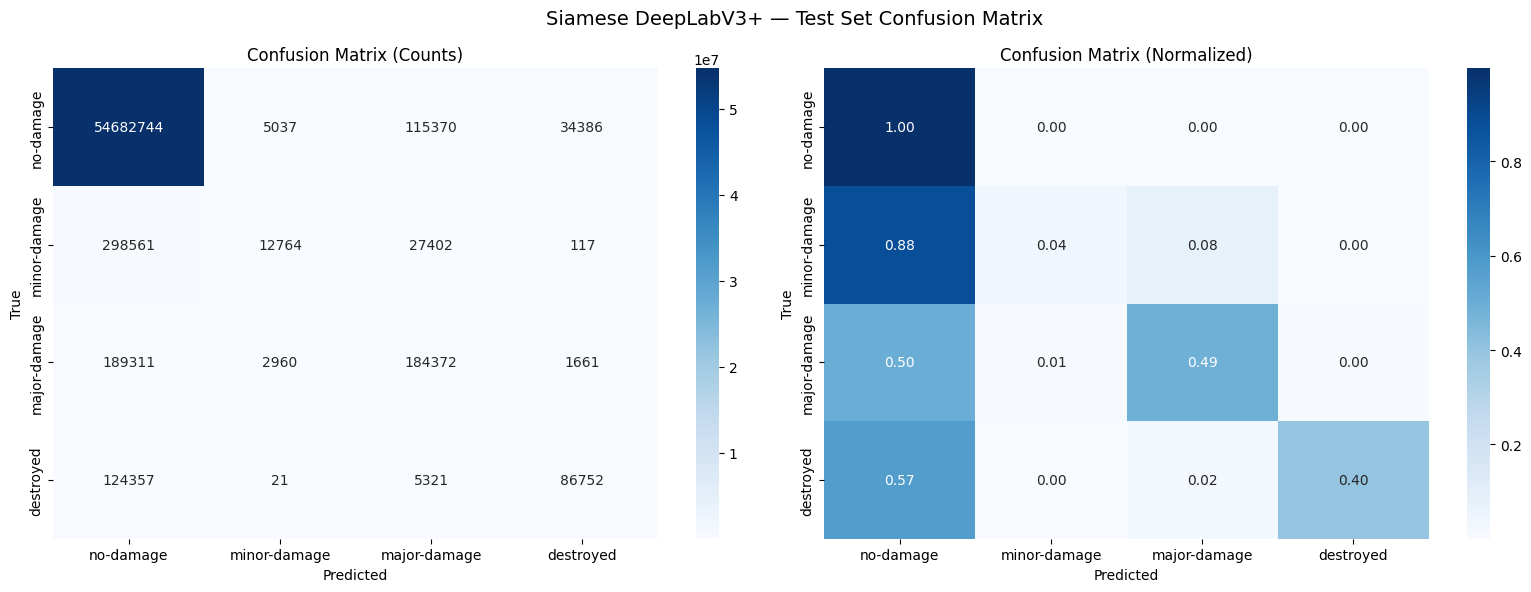

In [11]:
# --- cell 7: confusion matrix plot ---

# normalized confusion matrix heatmap
cm_normalized = confusion_mat.astype(float) / (confusion_mat.sum(axis=1, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# raw counts
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('Siamese DeepLabV3+ — Test Set Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

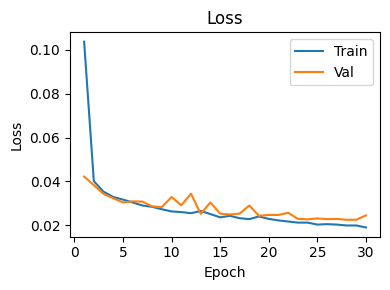

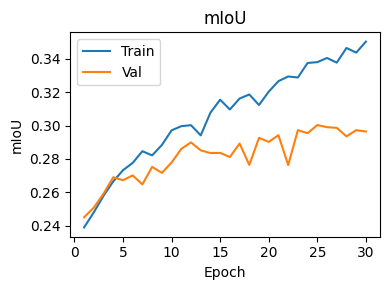

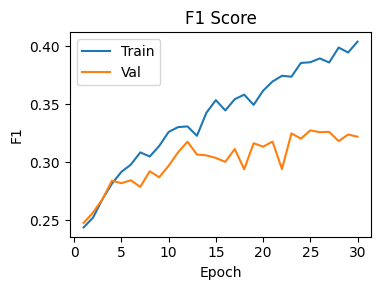

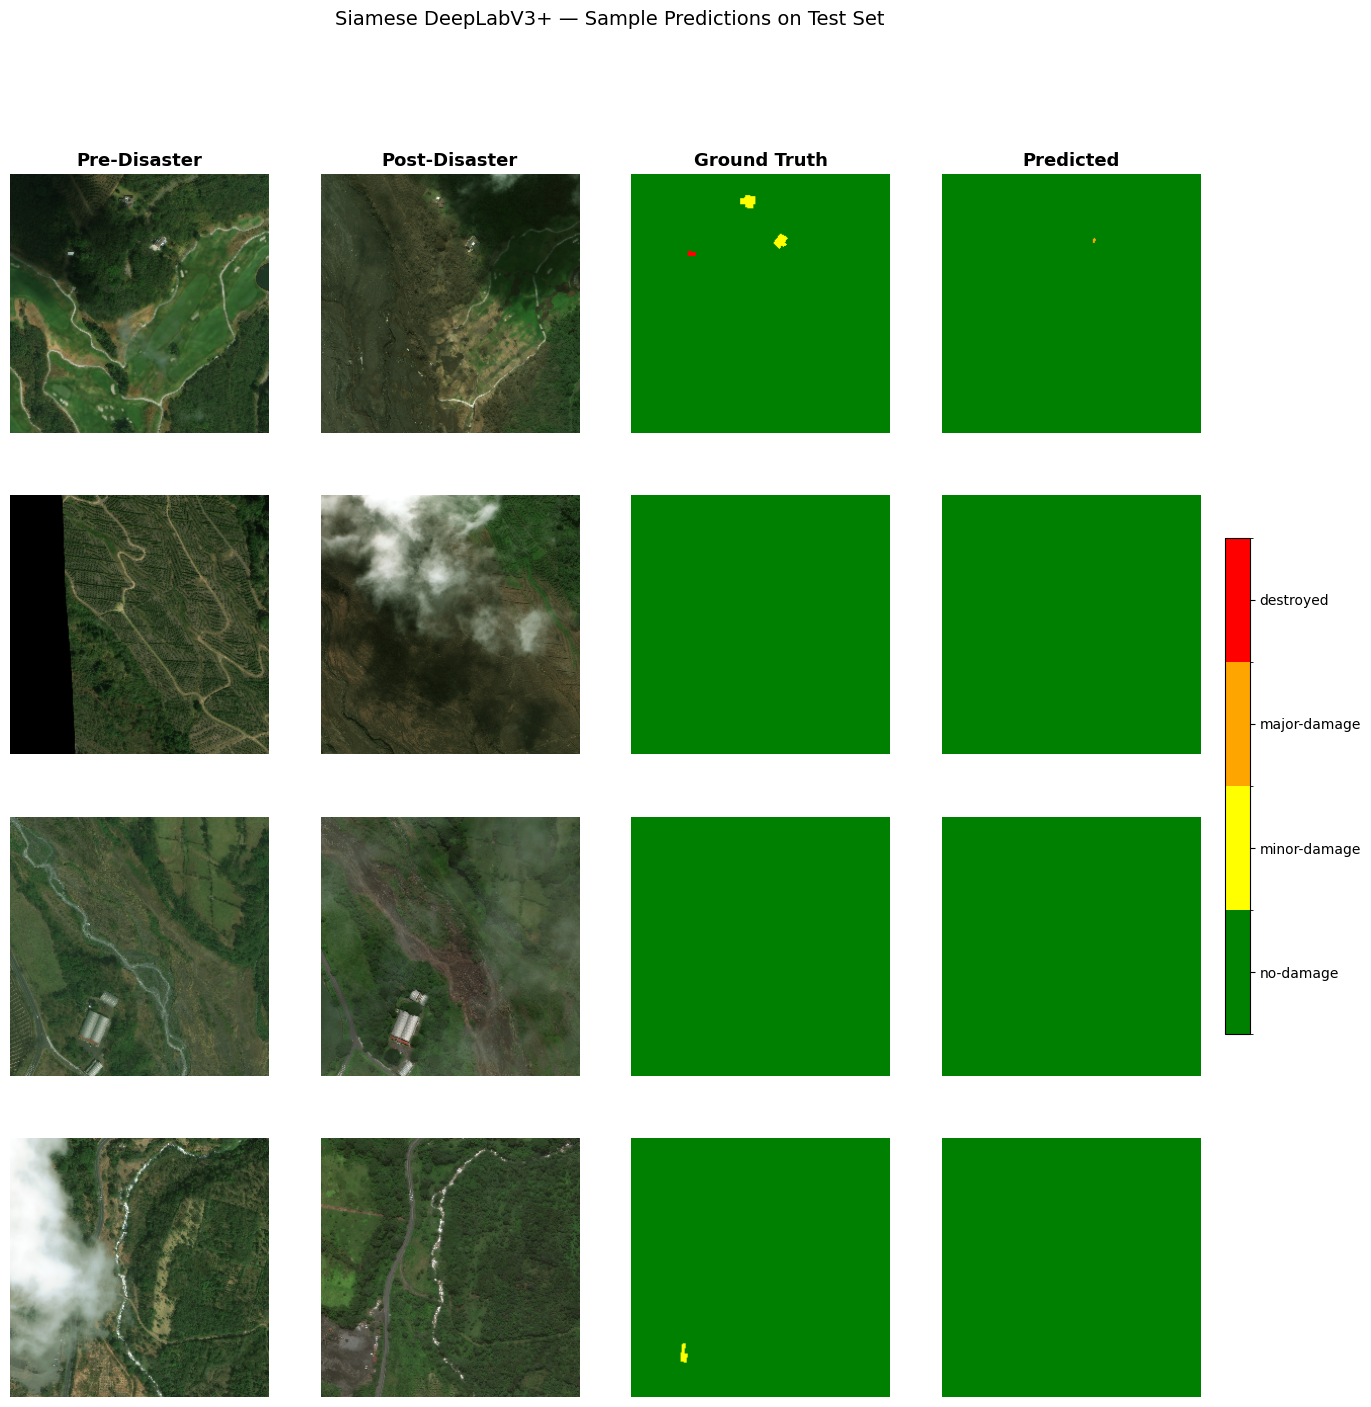

In [12]:
# --- cell 8: plot training curves ---
try:
    with open(HISTORY_PATH, 'r') as f:
        history = json.load(f)

    epochs = range(1, len(history['train_loss']) + 1)

    # loss plot
    plt.figure(figsize=(4, 3))
    plt.plot(epochs, history['train_loss'], label='Train')
    plt.plot(epochs, history['val_loss'], label='Val')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'loss.png', dpi=150, bbox_inches='tight')
    plt.show()

    # miou plot
    plt.figure(figsize=(4, 3))
    plt.plot(epochs, history['train_miou'], label='Train')
    plt.plot(epochs, history['val_miou'], label='Val')
    plt.title('mIoU')
    plt.xlabel('Epoch')
    plt.ylabel('mIoU')
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'miou.png', dpi=150, bbox_inches='tight')
    plt.show()

    # f1 plot
    plt.figure(figsize=(4, 3))
    plt.plot(epochs, history['train_f1'], label='Train')
    plt.plot(epochs, history['val_f1'], label='Val')
    plt.title('F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1')
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'f1.png', dpi=150, bbox_inches='tight')
    plt.show()
except FileNotFoundError:
    print(f"Skipping plots: Could not find training history file at {HISTORY_PATH}")


# --- cell 9: sample predictions ---
# damage class colormap: matches preprocessing labels
# 0=no-damage, 1=minor, 2=major, 3=destroyed
CMAP   = mcolors.ListedColormap(['green', 'yellow', 'orange', 'red'])
BOUNDS = [0, 1, 2, 3, 4]
NORM   = mcolors.BoundaryNorm(BOUNDS, CMAP.N)

def visualize_predictions(model, loader, device, num_samples=4):

    model.eval()
    samples_shown = 0

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))
    col_titles = ['Pre-Disaster', 'Post-Disaster', 'Ground Truth', 'Predicted']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=13, fontweight='bold')

    with torch.no_grad():
        for pre, post, masks in loader:
            pre   = pre.to(device)
            post  = post.to(device)

            with autocast('cuda'):
                outputs = model(pre, post)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()  # (batch, H, W)
            masks = masks.numpy()

            for i in range(pre.shape[0]):
                if samples_shown >= num_samples:
                    break

                # denormalize images back to [0, 255] for display
                
                pre_img  = pre[i].cpu().numpy().transpose(1, 2, 0)
                post_img = post[i].cpu().numpy().transpose(1, 2, 0)

                ax_row = axes[samples_shown]

                ax_row[0].imshow(pre_img)
                ax_row[0].axis('off')

                ax_row[1].imshow(post_img)
                ax_row[1].axis('off')

                ax_row[2].imshow(masks[i], cmap=CMAP, norm=NORM)
                ax_row[2].axis('off')

                ax_row[3].imshow(preds[i], cmap=CMAP, norm=NORM)
                ax_row[3].axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    # shared colorbar
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=NORM)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_ticks([0.5, 1.5, 2.5, 3.5])
    cbar.set_ticklabels(CLASS_NAMES)

    plt.suptitle('Siamese DeepLabV3+ — Sample Predictions on Test Set', fontsize=14)
    plt.savefig(CHECKPOINT_DIR / 'sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, test_loader, DEVICE, num_samples=4)